In [ ]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import warnings
warnings.filterwarnings('ignore')

from collections          import Counter
from sklearn.cluster      import KMeans
from Customer_dataset import data
processed_data=data.copy()
print(processed_data.head(10))

   Age  Income_Level  Gender_Male
0   23         70541            0
1   26         54168            1
2   29         73899            0
3   20         63381            1
4   25         38794            0
5   41         87188            0
6   55         94891            1
7   35         61003            1
8   43        116249            0
9   32         49083            0


In [3]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kMeans
##------------------------------------------------------------------------------
k     = 5
Kmeans_model = KMeans(n_clusters = k)
Kmeans_model.fit(data)  # xây dựng mô hình

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [4]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Kmeans_model,'../customer_clustering/Output/kMeans.mdl')

['../customer_clustering/Output/kMeans.mdl']

In [5]:
## Khai thác mô hình đã được xây dựng
Loaded_Kmeans_model = jlb.load('../customer_clustering/Output/kMeans.mdl')

In [6]:
## Các trọng tâm
print(f'*** {k} trọng tâm:')
print(Loaded_Kmeans_model.cluster_centers_)

*** 5 trọng tâm:
[[4.53175676e+01 1.39899345e+05 5.00000000e-01]
 [4.48290598e+01 6.21617991e+04 5.04273504e-01]
 [4.40704846e+01 3.47659251e+04 5.28634361e-01]
 [4.59377990e+01 1.15634488e+05 5.40669856e-01]
 [4.42527473e+01 8.96773407e+04 5.27472527e-01]]


In [7]:
## Kết quả gom cụm khách hàng
centroids       = Loaded_Kmeans_model.cluster_centers_
data['cluster'] = Loaded_Kmeans_model.labels_
print(data.head(5))

print('\nKích thước các clusters:', Counter(Loaded_Kmeans_model.labels_))
print('\nClusters lớn nhất:', Counter(Loaded_Kmeans_model.labels_).most_common(1))

   Age  Income_Level  Gender_Male  cluster
0   23         70541            0        1
1   26         54168            1        1
2   29         73899            0        1
3   20         63381            1        1
4   25         38794            0        2

Kích thước các clusters: Counter({np.int32(1): 234, np.int32(2): 227, np.int32(3): 209, np.int32(4): 182, np.int32(0): 148})

Clusters lớn nhất: [(np.int32(1), 234)]


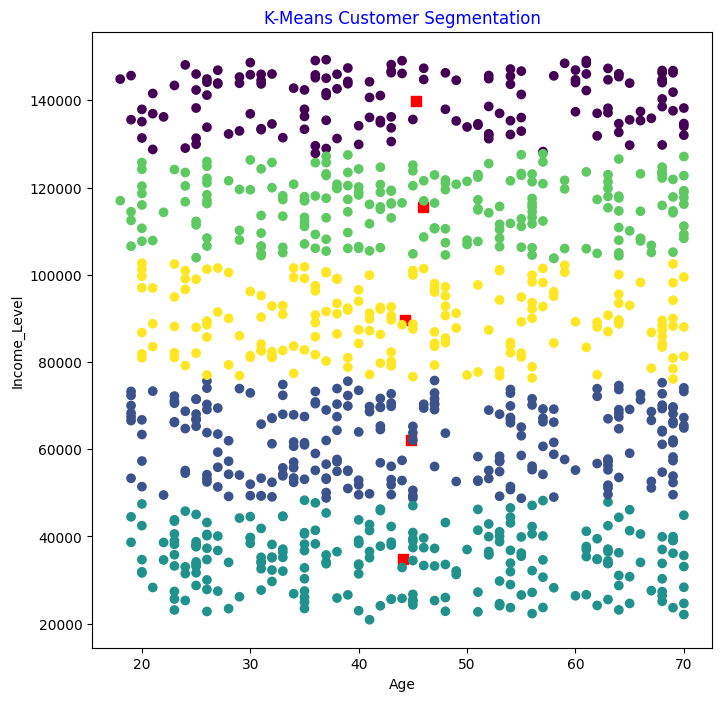

In [8]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
plt.scatter(centroids[:, 0], centroids[:, 1], marker = "s", s = 50, color = 'r')
plt.scatter(processed_data.Age, processed_data['Income_Level'], c = data.cluster)
plt.xlabel("Age")
plt.ylabel("Income_Level")
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()